# Dynamic Pool Adaptation


In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

analysis_dir = Path.cwd() / "analysis"
if str(analysis_dir) not in sys.path:
    sys.path.insert(0, str(analysis_dir))

from metrics import agents

pd.set_option("display.max_colwidth", 180)


: 

## 1. Task Adaptation Stability

OfficeBench compares read-only stale memory against continued memory updates under unchanged and changed agent pools. All conditions start from the same learned fold checkpoint and process the same test tasks. GAIA retains the original two-condition pool-stability comparison.

In [ ]:
print("OfficeBench")
display(agents.stability_table("officebench"))

print("GAIA")
display(agents.stability_table("gaia"))

## 2. Agent Adoption Rate


OfficeBench


,fold,agent,used_tasks,usage_rate (%),first_step,first_task_key
0,1,env_explorer,83,45.4,12,1-4/1
1,1,file_transformer,8,4.4,145,3-47/0
2,1,image_creator,13,7.1,46,1-19/2
3,2,env_explorer,45,26.0,19,1-7/0
4,2,file_transformer,3,1.7,123,3-14/1
5,2,image_creator,13,7.5,61,2-3/0
6,3,env_explorer,46,24.7,26,1-8/1
7,3,file_transformer,3,1.6,118,3-4/0
8,3,image_creator,14,7.5,43,1-18/0


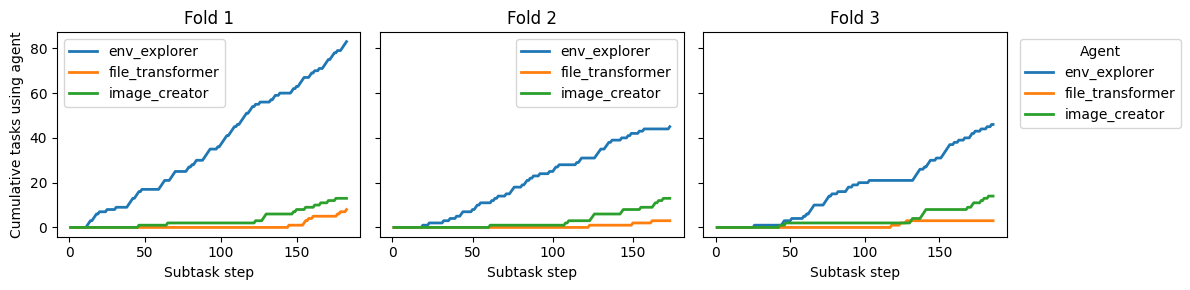

In [4]:
print("OfficeBench")
display(agents.adoption_rate("officebench"))

officebench_adoption = agents.adoption_by_fold("officebench")
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (fold, fold_data) in zip(axes, officebench_adoption.groupby("fold")):
    fold_data.drop(columns="fold").set_index("Step").plot(ax=ax, linewidth=2)
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Subtask step")
axes[0].set_ylabel("Cumulative tasks using agent")
axes[-1].legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


GAIA


,fold,agent,used_tasks,usage_rate (%),first_step,first_task_key
0,1,file_document_surfer,1,1.0,20,gaia-1-a3fbeb63/0
1,1,file_table_surfer,6,6.0,7,gaia-1-5cfb274c/0
2,1,file_image_surfer,10,10.0,18,gaia-1-9318445f/0
3,1,file_audio_surfer,0,0.0,<NA>,<NA>
4,2,file_document_surfer,4,4.0,28,gaia-1-cffe0e32/0
5,2,file_table_surfer,0,0.0,<NA>,<NA>
6,2,file_image_surfer,5,5.0,20,gaia-1-9318445f/0
7,2,file_audio_surfer,1,1.0,39,gaia-2-2b3ef98c/0
8,3,file_document_surfer,2,2.0,24,gaia-1-a3fbeb63/0
9,3,file_table_surfer,3,3.0,42,gaia-2-7cc4acfa/0


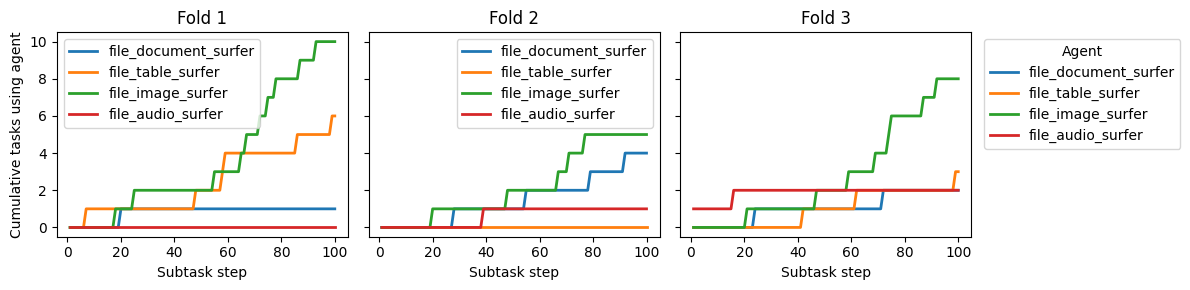

In [5]:
print("GAIA")
display(agents.adoption_rate("gaia"))

gaia_adoption = agents.adoption_by_fold("gaia")
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (fold, fold_data) in zip(axes, gaia_adoption.groupby("fold")):
    fold_data.drop(columns="fold").set_index("Step").plot(ax=ax, linewidth=2)
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Subtask step")
axes[0].set_ylabel("Cumulative tasks using agent")
axes[-1].legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()


## Agent Usage Shift Across All Tasks



In [6]:
print("OfficeBench all tasks, fold-averaged")
display(agents.agent_usage_shift_table("officebench", fold_average=True))

print("GAIA all tasks, fold-averaged")
display(agents.agent_usage_shift_table("gaia", fold_average=True))


OfficeBench all tasks, fold-averaged


,Agent,Task usage (%) Original,Task usage (%) Dynamic,Delta task usage (pp),Agent-use share (%) Original,Agent-use share (%) Dynamic,Delta agent-use share (pp)
0,shell,77.6,70.6,-7.0,35.9,26.8,-9.1
1,word,21.0,25.4,4.4,9.7,9.6,-0.0
2,excel,35.1,37.0,2.0,16.2,14.0,-2.1
3,pdf,15.5,16.9,1.4,7.2,6.4,-0.7
4,env_explorer,0.0,32.0,32.0,0.0,12.2,12.2
5,file_transformer,0.0,2.6,2.6,0.0,1.0,1.0
6,image_creator,0.0,7.4,7.4,0.0,2.8,2.8


GAIA all tasks, fold-averaged


,Agent,Task usage (%) Original,Task usage (%) Dynamic,Delta task usage (pp),Agent-use share (%) Original,Agent-use share (%) Dynamic,Delta agent-use share (pp)
0,file_surfer,23.7,16.3,-7.3,20.8,12.2,-8.7
1,file_document_surfer,0.0,2.3,2.3,0.0,1.8,1.8
2,file_table_surfer,0.0,3.0,3.0,0.0,2.2,2.2
3,file_image_surfer,0.0,7.7,7.7,0.0,5.7,5.7
4,file_audio_surfer,0.0,1.0,1.0,0.0,0.8,0.8


## Agent-Use Share Redistribution Plot


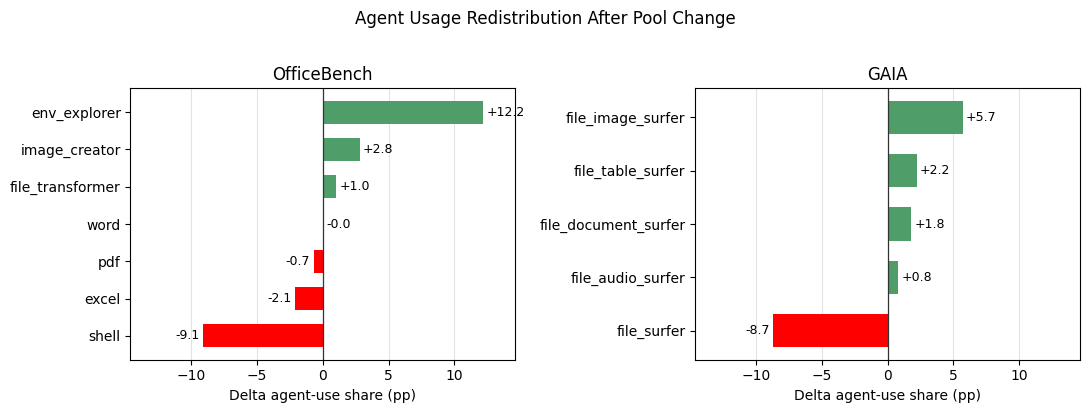

In [7]:
agent_use_shift_tables = {
    "OfficeBench": agents.agent_usage_shift_table(
        "officebench", fold_average=True
    ),
    "GAIA": agents.agent_usage_shift_table(
        "gaia", fold_average=True
    ),
}

max_abs_delta = max(
    table["Delta agent-use share (pp)"].abs().max()
    for table in agent_use_shift_tables.values()
)
x_limit = max_abs_delta * 1.2

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for ax, (benchmark, table) in zip(axes, agent_use_shift_tables.items()):
    plot_data = table[["Agent", "Delta agent-use share (pp)"]].sort_values(
        "Delta agent-use share (pp)"
    )
    values = plot_data["Delta agent-use share (pp)"]
    colors = ["#ff0000" if value < 0 else "#4f9d69" for value in values]

    ax.barh(plot_data["Agent"], values, color=colors, height=0.62)
    ax.axvline(0, color="#333333", linewidth=0.9)
    ax.set_title(benchmark)
    ax.set_xlabel("Delta agent-use share (pp)")
    ax.set_xlim(-x_limit, x_limit)
    ax.grid(axis="x", color="#dddddd", linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

    for agent, value in zip(plot_data["Agent"], values):
        offset = 0.25 if value >= 0 else -0.25
        ax.text(
            value + offset,
            agent,
            f"{value:+.1f}",
            va="center",
            ha="left" if value >= 0 else "right",
            fontsize=9,
        )

fig.suptitle("Agent Usage Redistribution After Pool Change", y=1.02)
plt.tight_layout()


## 3. Qualitative Playbook Activity


In [8]:
officebench_activity = agents.playbook_activity("officebench")

print("OfficeBench summary")
display(officebench_activity.groupby(["event_type", "agent", "section"]).size().rename("count").reset_index())

print("OfficeBench pruned bullets")
display(officebench_activity[officebench_activity["event_type"] == "pruned"])

print("OfficeBench added bullets")
display(officebench_activity[officebench_activity["event_type"] == "added"])


OfficeBench summary


,event_type,agent,section,count
0,added,env_explorer,capability,28
1,added,env_explorer,strategy,29
2,added,excel,capability,9
3,added,excel,limitation,8
4,added,excel,strategy,19
5,added,file_transformer,capability,6
6,added,file_transformer,limitation,3
7,added,file_transformer,strategy,5
8,added,image_creator,capability,9
9,added,image_creator,limitation,4


OfficeBench pruned bullets


,fold,event_type,agent,section,Step,task_key,bullet_id,rule
90,2,pruned,image_creator,capability,110,3-1/0,image_creator-3,Can create clean posters from event details you provide.
98,2,pruned,pdf,capability,112,3-5/0,pdf-6,Can create a Word document from extracted PDF content at an exact output path.
83,2,pruned,pdf,limitation,108,2-46/0,pdf-22,Cannot create PDFs from plain text or convert PDFs to JPG images in this environment.
93,2,pruned,word,limitation,111,3-3/0,word-8,Cannot convert Word to PDF unless a PDF action is available.
121,2,pruned,word,limitation,127,3-19/0,word-12,Cannot guarantee PDF conversion from a Word file.


OfficeBench added bullets


,fold,event_type,agent,section,Step,task_key,bullet_id,rule
0,1,added,env_explorer,capability,12,1-4/1,env_explorer-1,Can identify the most likely workbook among multiple spreadsheet candidates.
2,1,added,env_explorer,capability,13,1-4/2,env_explorer-2,Can scan a workspace for spreadsheet candidates and preview workbook structure.
47,2,added,env_explorer,capability,19,1-7/0,env_explorer-1,Can scan /testbed and rank candidate files by likely relevance.
53,2,added,env_explorer,capability,23,1-7/4,env_explorer-2,Can enumerate spreadsheet candidates across /testbed.
167,3,added,env_explorer,capability,26,1-8/1,env_explorer-1,Can locate a specific workbook by scanning /testbed.
...,...,...,...,...,...,...,...,...
119,2,added,word,strategy,127,3-19/0,word-11,"When overwriting a Word file, verify the read-back immediately; if old lines remain, treat the write as append-like and switch to a fresh path or stronger replacement instruction."
136,2,added,word,strategy,149,3-61/0,word-11,Verify the saved DOCX immediately after writing; read-back can reveal truncated or partially appended content.
146,2,added,word,strategy,157,3-75/0,word-10,"Avoid spaces in requested output filenames; if conversion fails, retry with a space-free exact path and verify the source DOCX text first."
155,2,added,word,strategy,162,3-84/0,word-15,"When source data lacks required variables, instruct the agent to state the missing fields explicitly and write a concise DOCX report at an exact path; it can produce a clean na..."


In [9]:
gaia_activity = agents.playbook_activity("gaia")

print("GAIA summary")
display(gaia_activity.groupby(["event_type", "agent", "section"]).size().rename("count").reset_index())

print("GAIA pruned bullets")
display(gaia_activity[gaia_activity["event_type"] == "pruned"])

print("GAIA added bullets")
display(gaia_activity[gaia_activity["event_type"] == "added"])


GAIA summary


,event_type,agent,section,count
0,added,file_audio_surfer,capability,3
1,added,file_audio_surfer,strategy,3
2,added,file_document_surfer,capability,5
3,added,file_document_surfer,limitation,2
4,added,file_document_surfer,strategy,7
5,added,file_image_surfer,capability,11
6,added,file_image_surfer,limitation,6
7,added,file_image_surfer,strategy,17
8,added,file_surfer,capability,5
9,added,file_surfer,limitation,17


GAIA pruned bullets


,fold,event_type,agent,section,Step,task_key,bullet_id,rule
64,2,pruned,file_surfer,capability,61,gaia-2-32102e3e/0,file_surfer-9,"Can analyze spreadsheets and Excel workbooks for sales, unusual values, and missing entries."


GAIA added bullets


,fold,event_type,agent,section,Step,task_key,bullet_id,rule
73,3,added,file_audio_surfer,capability,1,gaia-1-1f975693/0,file_audio_surfer-1,Can transcribe local audio attachments into transcript text.
77,3,added,file_audio_surfer,capability,16,gaia-1-99c9cc74/0,file_audio_surfer-2,Can extract normalized ingredient names from transcribed audio.
54,2,added,file_audio_surfer,capability,39,gaia-2-2b3ef98c/0,file_audio_surfer-4,Can transcribe local mp3 attachments from the active workdir.
74,3,added,file_audio_surfer,strategy,1,gaia-1-1f975693/0,file_audio_surfer-2,Specify the local audio filename and the exact extraction target; this specialist can return only the requested values in the required final format without extra explanation.
78,3,added,file_audio_surfer,strategy,16,gaia-1-99c9cc74/0,file_audio_surfer-4,"When requesting audio transcription, include the exact filename and the downstream extraction target; it can return transcript plus filtered results in one response."
...,...,...,...,...,...,...,...,...
49,1,added,file_table_surfer,limitation,99,gaia-3-da52d699/0,file_table_surfer-8,"Cannot compute reading rates without a word, page, or length field."
3,1,added,file_table_surfer,strategy,7,gaia-1-5cfb274c/0,file_table_surfer-2,"For spatial spreadsheet puzzles, specify the workbook, the relevant sheet, the cell color pattern, and the exact path rule to test."
86,3,added,file_table_surfer,strategy,42,gaia-2-7cc4acfa/0,file_table_surfer-2,"Specify the workbook path, relevant entities, and exact output constraint; this agent can then scan all sheets and aggregate values without extra guidance."
29,1,added,file_table_surfer,strategy,59,gaia-2-54612da3/0,file_table_surfer-6,"When asking for table rows, specify the workbook, request sheet discovery first, then name the headers and matching criterion to extract."
